# Notebook 04: Event-Study Returns and Dashboard Tables

## Academic Introduction

Notebook 04 converts the event-window prices prepared in Notebook 03 into return-based event-study metrics. The event window is based on trading days, specifically `t-5` to `t+5` around the event trading date. The stock return measures the company's raw price movement over that window, while the TA-125 return is used as a broad market benchmark.

The primary descriptive metric is the market-adjusted return, computed as stock return minus TA-125 return. This is an exploratory market-reaction analysis, not a causal identification design. Missing data, invalid tickers, future events, unavailable price series, and insufficient trading windows remain visible in the outputs through eligibility flags and exclusion reasons.

The final academic submission is the Streamlit dashboard. This notebook prepares the final analytical data layer for that dashboard; it does not fetch prices, modify ticker mappings, build the dashboard, or make causal claims.

## 1. Imports and Configuration

In [17]:
import json
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    stats = None
    SCIPY_AVAILABLE = False

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
DATA_INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
DATA_OUTPUT_DIR = PROJECT_ROOT / "data" / "output"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
EVENT_WINDOW_LABEL = "t-5_to_t+5"

DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GENERATED_AT = datetime.now(timezone.utc).isoformat()

print(f"Project root: {PROJECT_ROOT}")
print(f"SciPy available: {SCIPY_AVAILABLE}")

Project root: C:\Users\Guy\Desktop\Tene
SciPy available: True


## 2. Load Event Window Price Table

Notebook 04 depends on the event-window price table from Notebook 03. If this file is missing, Notebook 03 must be rerun before return calculations can proceed.

In [18]:
event_window_path = DATA_INTERIM_DIR / "event_window_prices_v01.csv"
if not event_window_path.exists():
    raise FileNotFoundError("Notebook 03 must be run before Notebook 04.")

event_window_df = pd.read_csv(event_window_path, encoding="utf-8-sig")

date_columns = [
    "event_date",
    "stock_t_minus_5_date",
    "stock_event_trading_date",
    "stock_t_plus_5_date",
    "market_t_minus_5_date",
    "market_event_trading_date",
    "market_t_plus_5_date",
]
for column in date_columns:
    if column in event_window_df.columns:
        event_window_df[column] = pd.to_datetime(event_window_df[column], errors="coerce")

numeric_price_columns = [
    "stock_price_t_minus_5",
    "stock_price_event",
    "stock_price_t_plus_5",
    "ta125_price_t_minus_5",
    "ta125_price_event",
    "ta125_price_t_plus_5",
]
for column in numeric_price_columns:
    if column in event_window_df.columns:
        event_window_df[column] = pd.to_numeric(event_window_df[column], errors="coerce")

print(f"Total rows: {len(event_window_df)}")
display(event_window_df["price_status"].value_counts(dropna=False).rename_axis("price_status").reset_index(name="event_count"))
display(event_window_df["market_price_status"].value_counts(dropna=False).rename_axis("market_price_status").reset_index(name="event_count"))
display(event_window_df["switch_type"].value_counts(dropna=False).rename_axis("switch_type").reset_index(name="event_count"))
print(f"Rows with OK stock windows: {int(event_window_df['price_status'].eq('OK').sum())}")
print(f"Rows with OK market windows: {int(event_window_df['market_price_status'].eq('OK').sum())}")
event_window_df.head()

Total rows: 50


,price_status,event_count
0,OK,36
1,TICKER_VALIDATION_FAILED,5
2,MISSING_TICKER,5
3,FUTURE_EVENT_DATE,2
4,NOT_ENOUGH_TRADING_DAYS_BEFORE,1
5,NOT_ENOUGH_TRADING_DAYS_AFTER,1


,market_price_status,event_count
0,OK,43
1,NaN,7


,switch_type,event_count
0,Small to Small,29
1,Big to Small,11
2,Small to Big,10


Rows with OK stock windows: 36
Rows with OK market windows: 43


,event_id,company_name,switch_type,event_date_basis,event_date,yahoo_ticker,google_finance_symbol,tase_security_id,isin,mapping_status,...,market_t_plus_5_date,ta125_price_t_minus_5,ta125_price_event,ta125_price_t_plus_5,market_price_source,market_price_status,market_price_notes,stock_price_rows_available,market_price_rows_available,extraction_timestamp
0,1,אבו מגורים,Small to Small,auditor_switch_date,2025-11-16,ABOU.TA,TLV:ABOU,1175819.0,NaN,MAPPED_MANUALLY,...,NaT,NaN,NaN,NaN,yfinance,OK,OK,21,1360,2026-05-27T12:18:24.769552+00:00
1,2,גלובל פיי-ש,Small to Small,auditor_switch_date,2025-02-19,GKL.TA,TLV:GKL,1141316.0,NaN,MAPPED_MANUALLY,...,2025-02-27,2568.449951,2602.629883,2542.520020,yfinance,OK,NaN,52,1360,2026-05-27T12:18:24.769552+00:00
2,3,"אמיליה פיתוח )מ.עו.פ.( בע""מ",Small to Small,auditor_switch_date,2026-02-17,EMDV.TA,TLV:EMDV,NaN,NaN,MAPPED_MANUALLY,...,2026-02-24,4161.870117,4168.120117,4116.350098,yfinance,OK,NaN,62,1360,2026-05-27T12:18:24.769552+00:00
3,4,"שדה נדל""ן",Small to Small,auditor_switch_date,2024-05-03,SADE.TA,TLV:SADE,NaN,IL0003410169,MAPPED_MANUALLY,...,2024-05-16,1962.229980,1966.829956,1997.000000,yfinance,OK,NaN,804,1360,2026-05-27T12:18:24.769552+00:00
4,5,ספידווליו,Big to Small,auditor_switch_date,2025-08-24,SPDV.TA,TLV:SPDV,1178284.0,NaN,MAPPED_MANUALLY,...,2025-09-02,3032.290039,3115.330078,3050.760010,yfinance,OK,NaN,45,1360,2026-05-27T12:18:24.769552+00:00


## 3. Define Analysis Eligibility

A row is eligible for return calculation only when the stock and market windows are both OK and the required start/end prices are numeric and positive. Excluded rows remain in the results table with an explicit `analysis_exclusion_reason`.

In [19]:
def determine_analysis_exclusion_reason(row):
    if row.get("price_status") != "OK":
        return "STOCK_PRICE_STATUS_NOT_OK"
    if row.get("market_price_status") != "OK":
        return "MARKET_PRICE_STATUS_NOT_OK"

    stock_start = row.get("stock_price_t_minus_5")
    stock_end = row.get("stock_price_t_plus_5")
    market_start = row.get("ta125_price_t_minus_5")
    market_end = row.get("ta125_price_t_plus_5")

    if pd.isna(stock_start) or pd.isna(stock_end):
        return "MISSING_STOCK_PRICE"
    if pd.isna(market_start) or pd.isna(market_end):
        return "MISSING_MARKET_PRICE"
    if stock_start <= 0 or stock_end <= 0:
        return "NON_POSITIVE_STOCK_PRICE"
    if market_start <= 0 or market_end <= 0:
        return "NON_POSITIVE_MARKET_PRICE"
    return "INCLUDED"


event_study_work_df = event_window_df.copy()
event_study_work_df["analysis_exclusion_reason"] = event_study_work_df.apply(determine_analysis_exclusion_reason, axis=1)
event_study_work_df["analysis_eligible"] = event_study_work_df["analysis_exclusion_reason"].eq("INCLUDED")

event_study_work_df[["event_id", "company_name", "price_status", "market_price_status", "analysis_eligible", "analysis_exclusion_reason"]].head(15)

,event_id,company_name,price_status,market_price_status,analysis_eligible,analysis_exclusion_reason
0,1,אבו מגורים,NOT_ENOUGH_TRADING_DAYS_BEFORE,OK,False,STOCK_PRICE_STATUS_NOT_OK
1,2,גלובל פיי-ש,OK,OK,True,INCLUDED
2,3,"אמיליה פיתוח )מ.עו.פ.( בע""מ",OK,OK,True,INCLUDED
3,4,"שדה נדל""ן",OK,OK,True,INCLUDED
4,5,ספידווליו,OK,OK,True,INCLUDED
5,6,הום ביוגז,OK,OK,True,INCLUDED
6,7,טוגדר,OK,OK,True,INCLUDED
7,8,אספן גרופ,NOT_ENOUGH_TRADING_DAYS_AFTER,OK,False,STOCK_PRICE_STATUS_NOT_OK
8,9,ג׳נסל בע״מ,FUTURE_EVENT_DATE,NaN,False,STOCK_PRICE_STATUS_NOT_OK
9,10,נופר אנרג׳י,FUTURE_EVENT_DATE,NaN,False,STOCK_PRICE_STATUS_NOT_OK


## 4. Return Calculations

For eligible rows, the stock return and TA-125 return are calculated from `t-5` to `t+5`. The market-adjusted return is the difference between these two returns. Event-day position metrics are also calculated where event-day prices are present.

In [20]:
for column in [
    "stock_return",
    "ta125_return",
    "market_adjusted_return",
    "stock_event_day_position",
    "ta125_event_day_position",
    "market_adjusted_event_day_position",
]:
    event_study_work_df[column] = np.nan

eligible_mask = event_study_work_df["analysis_eligible"]

event_study_work_df.loc[eligible_mask, "stock_return"] = (
    event_study_work_df.loc[eligible_mask, "stock_price_t_plus_5"]
    / event_study_work_df.loc[eligible_mask, "stock_price_t_minus_5"]
    - 1
)
event_study_work_df.loc[eligible_mask, "ta125_return"] = (
    event_study_work_df.loc[eligible_mask, "ta125_price_t_plus_5"]
    / event_study_work_df.loc[eligible_mask, "ta125_price_t_minus_5"]
    - 1
)
event_study_work_df.loc[eligible_mask, "market_adjusted_return"] = (
    event_study_work_df.loc[eligible_mask, "stock_return"]
    - event_study_work_df.loc[eligible_mask, "ta125_return"]
)

event_price_mask = (
    eligible_mask
    & event_study_work_df["stock_price_event"].notna()
    & event_study_work_df["ta125_price_event"].notna()
    & (event_study_work_df["stock_price_t_minus_5"] > 0)
    & (event_study_work_df["ta125_price_t_minus_5"] > 0)
)
event_study_work_df.loc[event_price_mask, "stock_event_day_position"] = (
    event_study_work_df.loc[event_price_mask, "stock_price_event"]
    / event_study_work_df.loc[event_price_mask, "stock_price_t_minus_5"]
    - 1
)
event_study_work_df.loc[event_price_mask, "ta125_event_day_position"] = (
    event_study_work_df.loc[event_price_mask, "ta125_price_event"]
    / event_study_work_df.loc[event_price_mask, "ta125_price_t_minus_5"]
    - 1
)
event_study_work_df.loc[event_price_mask, "market_adjusted_event_day_position"] = (
    event_study_work_df.loc[event_price_mask, "stock_event_day_position"]
    - event_study_work_df.loc[event_price_mask, "ta125_event_day_position"]
)

percentage_columns = {
    "stock_return": "stock_return_pct",
    "ta125_return": "ta125_return_pct",
    "market_adjusted_return": "market_adjusted_return_pct",
    "stock_event_day_position": "stock_event_day_position_pct",
    "ta125_event_day_position": "ta125_event_day_position_pct",
    "market_adjusted_event_day_position": "market_adjusted_event_day_position_pct",
}
for decimal_column, pct_column in percentage_columns.items():
    event_study_work_df[pct_column] = event_study_work_df[decimal_column] * 100

event_study_work_df.loc[eligible_mask, [
    "company_name",
    "stock_return",
    "ta125_return",
    "market_adjusted_return",
    "stock_return_pct",
    "ta125_return_pct",
    "market_adjusted_return_pct",
]].head()

,company_name,stock_return,ta125_return,market_adjusted_return,stock_return_pct,ta125_return_pct,market_adjusted_return_pct
1,גלובל פיי-ש,-0.069087,-0.010096,-0.058991,-6.908667,-1.009556,-5.899111
2,"אמיליה פיתוח )מ.עו.פ.( בע""מ",0.007687,-0.010937,0.018624,0.768693,-1.093740,1.862433
3,"שדה נדל""ן",0.000000,0.017720,-0.017720,0.000000,1.771965,-1.771965
4,ספידווליו,0.051051,0.006091,0.044960,5.105105,0.609110,4.495995
5,הום ביוגז,-0.129886,0.005651,-0.135537,-12.988578,0.565131,-13.553709


## 5. Classification of Market Reaction

The reaction classification is descriptive. A market-adjusted return greater than 0.5 percentage points is labeled positive; less than -0.5 percentage points is labeled negative; otherwise it is neutral.

In [21]:
def classify_reaction(value):
    if pd.isna(value):
        return "Not calculated"
    if value > 0.005:
        return "Positive"
    if value < -0.005:
        return "Negative"
    return "Neutral"


def describe_outlier(row):
    if not row.get("analysis_eligible", False) or pd.isna(row.get("market_adjusted_return")):
        return ""
    abs_return = abs(row["market_adjusted_return"])
    if abs_return >= 0.50:
        return "Extreme return; verify ticker, corporate actions, liquidity, and event-date validity."
    if abs_return >= 0.20:
        return "Large return; recommended manual review."
    return ""


event_study_work_df["reaction_direction"] = event_study_work_df["market_adjusted_return"].apply(classify_reaction)
event_study_work_df["absolute_market_adjusted_return"] = event_study_work_df["market_adjusted_return"].abs()
event_study_work_df["is_extreme_market_adjusted_return_20pct"] = (
    event_study_work_df["analysis_eligible"]
    & event_study_work_df["absolute_market_adjusted_return"].ge(0.20)
)
event_study_work_df["is_extreme_market_adjusted_return_50pct"] = (
    event_study_work_df["analysis_eligible"]
    & event_study_work_df["absolute_market_adjusted_return"].ge(0.50)
)
event_study_work_df["outlier_note"] = event_study_work_df.apply(describe_outlier, axis=1)

event_study_work_df[[
    "reaction_direction",
    "is_extreme_market_adjusted_return_20pct",
    "is_extreme_market_adjusted_return_50pct",
]].value_counts(dropna=False)

reaction_direction  is_extreme_market_adjusted_return_20pct  is_extreme_market_adjusted_return_50pct
Negative            False                                    False                                      18
Not calculated      False                                    False                                      14
Positive            False                                    False                                      11
Neutral             False                                    False                                       3
Negative            True                                     True                                        1
                                                             False                                       1
Positive            True                                     False                                       1
                                                             True                                        1
Name: count, dtype: int64

## 6. Main Event Study Results Table

The main table preserves all event rows and appends return metrics, eligibility flags, and exclusion reasons. This is the central analytical table for the dashboard.

In [22]:
EVENT_STUDY_RESULTS_COLUMNS = [
    "event_id",
    "company_name",
    "switch_type",
    "event_date_basis",
    "event_date",
    "yahoo_ticker",
    "mapping_status",
    "mapping_confidence",
    "stock_t_minus_5_date",
    "stock_event_trading_date",
    "stock_t_plus_5_date",
    "market_t_minus_5_date",
    "market_event_trading_date",
    "market_t_plus_5_date",
    "stock_price_t_minus_5",
    "stock_price_event",
    "stock_price_t_plus_5",
    "ta125_price_t_minus_5",
    "ta125_price_event",
    "ta125_price_t_plus_5",
    "price_status",
    "market_price_status",
    "analysis_eligible",
    "analysis_exclusion_reason",
    "price_notes",
    "market_price_notes",
    "stock_return",
    "ta125_return",
    "market_adjusted_return",
    "stock_return_pct",
    "ta125_return_pct",
    "market_adjusted_return_pct",
    "stock_event_day_position",
    "ta125_event_day_position",
    "market_adjusted_event_day_position",
    "stock_event_day_position_pct",
    "ta125_event_day_position_pct",
    "market_adjusted_event_day_position_pct",
    "reaction_direction",
    "absolute_market_adjusted_return",
    "is_extreme_market_adjusted_return_20pct",
    "is_extreme_market_adjusted_return_50pct",
    "outlier_note",
]

missing_result_columns = [column for column in EVENT_STUDY_RESULTS_COLUMNS if column not in event_study_work_df.columns]
if missing_result_columns:
    raise ValueError(f"Event-study results table missing required columns: {missing_result_columns}")

event_study_results_df = event_study_work_df[EVENT_STUDY_RESULTS_COLUMNS].copy()

event_study_results_csv_path = DATA_OUTPUT_DIR / "event_study_results_v01.csv"
event_study_results_xlsx_path = DATA_OUTPUT_DIR / "event_study_results_v01.xlsx"
event_study_results_df.to_csv(event_study_results_csv_path, index=False, encoding="utf-8-sig")
event_study_results_df.to_excel(event_study_results_xlsx_path, index=False)

event_study_results_df.head()

,event_id,company_name,switch_type,event_date_basis,event_date,yahoo_ticker,mapping_status,mapping_confidence,stock_t_minus_5_date,stock_event_trading_date,...,ta125_event_day_position,market_adjusted_event_day_position,stock_event_day_position_pct,ta125_event_day_position_pct,market_adjusted_event_day_position_pct,reaction_direction,absolute_market_adjusted_return,is_extreme_market_adjusted_return_20pct,is_extreme_market_adjusted_return_50pct,outlier_note
0,1,אבו מגורים,Small to Small,auditor_switch_date,2025-11-16,ABOU.TA,MAPPED_MANUALLY,HIGH,NaT,2025-11-17,...,NaN,NaN,NaN,NaN,NaN,Not calculated,NaN,False,False,
1,2,גלובל פיי-ש,Small to Small,auditor_switch_date,2025-02-19,GKL.TA,MAPPED_MANUALLY,HIGH,2025-02-11,2025-02-19,...,0.013308,-0.032043,-1.873534,1.330761,-3.204296,Negative,0.058991,False,False,
2,3,"אמיליה פיתוח )מ.עו.פ.( בע""מ",Small to Small,auditor_switch_date,2026-02-17,EMDV.TA,MAPPED_MANUALLY,HIGH,2026-02-10,2026-02-17,...,0.001502,0.011077,1.257862,0.150173,1.107689,Positive,0.018624,False,False,
3,4,"שדה נדל""ן",Small to Small,auditor_switch_date,2024-05-03,SADE.TA,MAPPED_MANUALLY,HIGH,2024-04-24,2024-05-06,...,0.002344,0.001359,0.370370,0.234426,0.135944,Negative,0.017720,False,False,
4,5,ספידווליו,Big to Small,auditor_switch_date,2025-08-24,SPDV.TA,MAPPED_MANUALLY,HIGH,2025-08-14,2025-08-25,...,0.027385,0.014657,4.204204,2.738526,1.465679,Positive,0.044960,False,False,


## 7. Dashboard Summary KPIs

The KPI table is a one-row dashboard input summarizing sample size, eligibility, return distributions, reaction counts, and common exclusion categories.

In [23]:
eligible_df = event_study_results_df.loc[event_study_results_df["analysis_eligible"]].copy()
eligible_without_20pct_outliers_df = eligible_df.loc[
    ~eligible_df["is_extreme_market_adjusted_return_20pct"].fillna(False)
].copy()

def safe_mean(series):
    return float(series.mean()) if series.notna().any() else np.nan


def safe_median(series):
    return float(series.median()) if series.notna().any() else np.nan


def safe_std(series):
    return float(series.std(ddof=1)) if series.notna().sum() >= 2 else np.nan


def safe_min(series):
    return float(series.min()) if series.notna().any() else np.nan


def safe_max(series):
    return float(series.max()) if series.notna().any() else np.nan


not_enough_trading_days_count = int(event_study_results_df["price_status"].isin([
    "NOT_ENOUGH_TRADING_DAYS_BEFORE",
    "NOT_ENOUGH_TRADING_DAYS_AFTER",
]).sum())
number_of_20pct_outliers = int(event_study_results_df["is_extreme_market_adjusted_return_20pct"].fillna(False).sum())
number_of_50pct_outliers = int(event_study_results_df["is_extreme_market_adjusted_return_50pct"].fillna(False).sum())

kpis = {
    "total_events": int(len(event_study_results_df)),
    "analysis_eligible_events": int(event_study_results_df["analysis_eligible"].sum()),
    "excluded_events": int((~event_study_results_df["analysis_eligible"]).sum()),
    "eligibility_rate": round(float(event_study_results_df["analysis_eligible"].mean()), 4) if len(event_study_results_df) else 0.0,
    "mean_stock_return": safe_mean(eligible_df["stock_return"]),
    "median_stock_return": safe_median(eligible_df["stock_return"]),
    "mean_ta125_return": safe_mean(eligible_df["ta125_return"]),
    "median_ta125_return": safe_median(eligible_df["ta125_return"]),
    "mean_market_adjusted_return": safe_mean(eligible_df["market_adjusted_return"]),
    "median_market_adjusted_return": safe_median(eligible_df["market_adjusted_return"]),
    "std_market_adjusted_return": safe_std(eligible_df["market_adjusted_return"]),
    "min_market_adjusted_return": safe_min(eligible_df["market_adjusted_return"]),
    "max_market_adjusted_return": safe_max(eligible_df["market_adjusted_return"]),
    "mean_market_adjusted_return_excluding_20pct_outliers": safe_mean(eligible_without_20pct_outliers_df["market_adjusted_return"]),
    "median_market_adjusted_return_excluding_20pct_outliers": safe_median(eligible_without_20pct_outliers_df["market_adjusted_return"]),
    "number_of_20pct_outliers": number_of_20pct_outliers,
    "number_of_50pct_outliers": number_of_50pct_outliers,
    "positive_reactions_count": int(eligible_df["reaction_direction"].eq("Positive").sum()),
    "negative_reactions_count": int(eligible_df["reaction_direction"].eq("Negative").sum()),
    "neutral_reactions_count": int(eligible_df["reaction_direction"].eq("Neutral").sum()),
    "missing_ticker_count": int(event_study_results_df["price_status"].eq("MISSING_TICKER").sum()),
    "ticker_validation_failed_count": int(event_study_results_df["price_status"].eq("TICKER_VALIDATION_FAILED").sum()),
    "future_event_count": int(event_study_results_df["price_status"].eq("FUTURE_EVENT_DATE").sum()),
    "missing_stock_price_count": int(event_study_results_df["price_status"].eq("MISSING_STOCK_PRICE_DATA").sum()),
    "missing_market_price_count": int(event_study_results_df["price_status"].eq("MISSING_MARKET_PRICE_DATA").sum()),
    "not_enough_trading_days_count": not_enough_trading_days_count,
    "generated_at": GENERATED_AT,
}

dashboard_summary_kpis_df = pd.DataFrame([kpis])
kpi_csv_path = DATA_OUTPUT_DIR / "dashboard_summary_kpis_v01.csv"
kpi_json_path = DATA_OUTPUT_DIR / "dashboard_summary_kpis_v01.json"
dashboard_summary_kpis_df.to_csv(kpi_csv_path, index=False, encoding="utf-8-sig")
kpi_json_path.write_text(
    json.dumps(kpis, ensure_ascii=False, indent=2, sort_keys=True),
    encoding="utf-8",
)
dashboard_summary_kpis_df

,total_events,analysis_eligible_events,excluded_events,eligibility_rate,mean_stock_return,median_stock_return,mean_ta125_return,median_ta125_return,mean_market_adjusted_return,median_market_adjusted_return,...,positive_reactions_count,negative_reactions_count,neutral_reactions_count,missing_ticker_count,ticker_validation_failed_count,future_event_count,missing_stock_price_count,missing_market_price_count,not_enough_trading_days_count,generated_at
0,50,36,14,0.72,-0.016176,-0.018083,0.00077,0.010107,-0.016946,-0.01317,...,13,20,3,5,5,2,0,0,2,2026-05-27T12:38:40.258605+00:00


## 8. Summary by Switch Type

The switch-type summary supports dashboard comparison across auditor-transition categories while preserving eligibility rates and exclusion counts.

In [24]:
def summarize_switch_type(group):
    eligible_group = group.loc[group["analysis_eligible"]]
    robust_group = eligible_group.loc[
        ~eligible_group["is_extreme_market_adjusted_return_20pct"].fillna(False)
    ]
    total = len(group)
    eligible = int(group["analysis_eligible"].sum())
    summary = {
        "total_events": int(total),
        "eligible_events": eligible,
        "excluded_events": int(total - eligible),
        "eligibility_rate": round(float(eligible / total), 4) if total else 0.0,
        "mean_stock_return": safe_mean(eligible_group["stock_return"]),
        "median_stock_return": safe_median(eligible_group["stock_return"]),
        "mean_ta125_return": safe_mean(eligible_group["ta125_return"]),
        "median_ta125_return": safe_median(eligible_group["ta125_return"]),
        "mean_market_adjusted_return": safe_mean(eligible_group["market_adjusted_return"]),
        "median_market_adjusted_return": safe_median(eligible_group["market_adjusted_return"]),
        "std_market_adjusted_return": safe_std(eligible_group["market_adjusted_return"]),
        "min_market_adjusted_return": safe_min(eligible_group["market_adjusted_return"]),
        "max_market_adjusted_return": safe_max(eligible_group["market_adjusted_return"]),
        "mean_market_adjusted_return_excluding_20pct_outliers": safe_mean(robust_group["market_adjusted_return"]),
        "median_market_adjusted_return_excluding_20pct_outliers": safe_median(robust_group["market_adjusted_return"]),
        "number_of_20pct_outliers": int(group["is_extreme_market_adjusted_return_20pct"].fillna(False).sum()),
        "number_of_50pct_outliers": int(group["is_extreme_market_adjusted_return_50pct"].fillna(False).sum()),
        "positive_reactions_count": int(eligible_group["reaction_direction"].eq("Positive").sum()),
        "negative_reactions_count": int(eligible_group["reaction_direction"].eq("Negative").sum()),
        "neutral_reactions_count": int(eligible_group["reaction_direction"].eq("Neutral").sum()),
    }
    summary["mean_stock_return_pct"] = summary["mean_stock_return"] * 100 if pd.notna(summary["mean_stock_return"]) else np.nan
    summary["mean_ta125_return_pct"] = summary["mean_ta125_return"] * 100 if pd.notna(summary["mean_ta125_return"]) else np.nan
    summary["mean_market_adjusted_return_pct"] = summary["mean_market_adjusted_return"] * 100 if pd.notna(summary["mean_market_adjusted_return"]) else np.nan
    summary["mean_market_adjusted_return_excluding_20pct_outliers_pct"] = (
        summary["mean_market_adjusted_return_excluding_20pct_outliers"] * 100
        if pd.notna(summary["mean_market_adjusted_return_excluding_20pct_outliers"]) else np.nan
    )
    return pd.Series(summary)


dashboard_switch_type_summary_df = (
    event_study_results_df
    .groupby("switch_type", dropna=False)
    .apply(summarize_switch_type)
    .reset_index()
)

switch_summary_csv_path = DATA_OUTPUT_DIR / "dashboard_switch_type_summary_v01.csv"
switch_summary_xlsx_path = DATA_OUTPUT_DIR / "dashboard_switch_type_summary_v01.xlsx"
dashboard_switch_type_summary_df.to_csv(switch_summary_csv_path, index=False, encoding="utf-8-sig")
dashboard_switch_type_summary_df.to_excel(switch_summary_xlsx_path, index=False)

dashboard_switch_type_summary_df

C:\Users\Guy\AppData\Local\Temp\ipykernel_48736\2901090678.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_switch_type)


,switch_type,total_events,eligible_events,excluded_events,eligibility_rate,mean_stock_return,median_stock_return,mean_ta125_return,median_ta125_return,mean_market_adjusted_return,...,median_market_adjusted_return_excluding_20pct_outliers,number_of_20pct_outliers,number_of_50pct_outliers,positive_reactions_count,negative_reactions_count,neutral_reactions_count,mean_stock_return_pct,mean_ta125_return_pct,mean_market_adjusted_return_pct,mean_market_adjusted_return_excluding_20pct_outliers_pct
0,Big to Small,11.0,7.0,4.0,0.6364,-0.033873,-0.022249,-0.004242,0.006091,-0.029632,...,0.020802,0.0,0.0,4.0,3.0,0.0,-3.387336,-0.424172,-2.963164,-2.963164
1,Small to Big,10.0,8.0,2.0,0.8000,0.059146,-0.037391,-0.003110,0.025558,0.062256,...,-0.039552,2.0,1.0,3.0,5.0,0.0,5.914560,-0.311011,6.225571,-4.119625
2,Small to Small,29.0,21.0,8.0,0.7241,-0.038970,-0.016935,0.003919,0.004546,-0.042889,...,-0.008620,2.0,1.0,6.0,12.0,3.0,-3.897036,0.391876,-4.288912,-1.079334


## 8.5 Outlier Report

Extreme market-adjusted returns are retained in the main event-study results. This report isolates large observations for manual verification of ticker mapping, corporate actions, liquidity, and event-date validity.

In [25]:
OUTLIER_REPORT_COLUMNS = [
    "event_id",
    "company_name",
    "switch_type",
    "event_date",
    "yahoo_ticker",
    "stock_return_pct",
    "ta125_return_pct",
    "market_adjusted_return_pct",
    "reaction_direction",
    "outlier_note",
]

dashboard_outlier_report_df = event_study_results_df.loc[
    event_study_results_df["is_extreme_market_adjusted_return_20pct"].fillna(False),
    OUTLIER_REPORT_COLUMNS,
].sort_values("market_adjusted_return_pct", key=lambda s: s.abs(), ascending=False)

outlier_report_csv_path = DATA_OUTPUT_DIR / "dashboard_outlier_report_v01.csv"
outlier_report_xlsx_path = DATA_OUTPUT_DIR / "dashboard_outlier_report_v01.xlsx"
dashboard_outlier_report_df.to_csv(outlier_report_csv_path, index=False, encoding="utf-8-sig")
dashboard_outlier_report_df.to_excel(outlier_report_xlsx_path, index=False)
dashboard_outlier_report_df


,event_id,company_name,switch_type,event_date,yahoo_ticker,stock_return_pct,ta125_return_pct,market_adjusted_return_pct,reaction_direction,outlier_note
19,20,"שדה נדל""ן",Small to Big,2020-07-09,SADE.TA,100.774840,1.811421,98.963420,Positive,"Extreme return; verify ticker, corporate actio..."
24,25,אקסיליון,Small to Small,2020-09-08,AILN.TA,-99.205781,-4.709472,-94.496310,Negative,"Extreme return; verify ticker, corporate actio..."
33,34,פסיירקס ביוטק,Small to Small,2026-02-12,PSRX.TA,28.556373,3.619868,24.936506,Positive,Large return; recommended manual review.
47,48,איי ארגנטו,Small to Big,2024-02-11,IARG.TA,-19.857769,4.583336,-24.441105,Negative,Large return; recommended manual review.


## 9. Top Positive and Top Negative Reactions

These tables show the largest positive and negative market-adjusted returns among eligible observations. They are descriptive rankings, not evidence of causality.

In [26]:
top_reaction_columns = [
    "company_name",
    "switch_type",
    "event_date",
    "yahoo_ticker",
    "stock_return_pct",
    "ta125_return_pct",
    "market_adjusted_return_pct",
    "reaction_direction",
]

dashboard_top_positive_reactions_df = (
    eligible_df
    .sort_values("market_adjusted_return", ascending=False)
    .head(10)[top_reaction_columns]
    .copy()
)
dashboard_top_negative_reactions_df = (
    eligible_df
    .sort_values("market_adjusted_return", ascending=True)
    .head(10)[top_reaction_columns]
    .copy()
)

top_positive_csv_path = DATA_OUTPUT_DIR / "dashboard_top_positive_reactions_v01.csv"
top_negative_csv_path = DATA_OUTPUT_DIR / "dashboard_top_negative_reactions_v01.csv"
dashboard_top_positive_reactions_df.to_csv(top_positive_csv_path, index=False, encoding="utf-8-sig")
dashboard_top_negative_reactions_df.to_csv(top_negative_csv_path, index=False, encoding="utf-8-sig")

display(dashboard_top_positive_reactions_df)
display(dashboard_top_negative_reactions_df)

,company_name,switch_type,event_date,yahoo_ticker,stock_return_pct,ta125_return_pct,market_adjusted_return_pct,reaction_direction
19,"שדה נדל""ן",Small to Big,2020-07-09,SADE.TA,100.774840,1.811421,98.963420,Positive
33,פסיירקס ביוטק,Small to Small,2026-02-12,PSRX.TA,28.556373,3.619868,24.936506,Positive
26,ישראל קנדה מלונות,Small to Small,2025-10-11,ICHO.TA,26.232740,6.768710,19.464029,Positive
6,טוגדר,Small to Small,2025-07-28,TGTR.TA,5.692807,-2.726972,8.419779,Positive
21,שירותי בנק אוטו,Big to Small,2020-08-16,SHVA.TA,9.170307,1.810575,7.359732,Positive
23,חג׳ג׳ אירופה,Small to Big,2025-11-06,HGGE.TA,10.761590,5.044633,5.716957,Positive
4,ספידווליו,Big to Small,2025-08-24,SPDV.TA,5.105105,0.609110,4.495995,Positive
31,ישראכרט,Small to Big,2020-07-16,ISCD.TA,5.469481,2.561080,2.908401,Positive
25,בוני תיכון,Big to Small,2020-02-08,BOTI.TA,3.632558,1.268764,2.363794,Positive
37,מטריקס,Big to Small,2024-04-03,MTRX.TA,-2.224939,-4.305132,2.080193,Positive


,company_name,switch_type,event_date,yahoo_ticker,stock_return_pct,ta125_return_pct,market_adjusted_return_pct,reaction_direction
24,אקסיליון,Small to Small,2020-09-08,AILN.TA,-99.205781,-4.709472,-94.496310,Negative
47,איי ארגנטו,Small to Big,2024-02-11,IARG.TA,-19.857769,4.583336,-24.441105,Negative
46,ביולייט,Big to Small,2019-11-10,BOLT.TA,-15.662002,1.211049,-16.873051,Negative
39,ברק בית השקעות,Small to Big,2020-03-17,BARI.TA,-34.778192,-19.471193,-15.306999,Negative
5,הום ביוגז,Big to Small,2024-07-17,HMGS.TA,-12.988578,0.565131,-13.553709,Negative
44,תעוזה,Small to Small,2020-01-28,TUZA.TA,-13.646058,-0.303834,-13.342225,Negative
36,פרידנזון,Small to Big,2020-05-14,FRDN.TA,-7.575208,2.550457,-10.125665,Negative
10,תמר פטרוליום,Small to Small,2026-03-31,TMRP.TA,-5.888920,2.460414,-8.349334,Negative
30,תמיס,Small to Small,2026-01-12,TMIS.TA,-1.693548,5.104956,-6.798504,Negative
22,אוטונומוס,Big to Small,2025-07-30,AGRD.TA,-10.743802,-4.128700,-6.615101,Negative


## 10. Exclusion Report

Excluded rows are grouped by exclusion reason and underlying price statuses. A row-level excluded-events table is also retained for transparency.

In [27]:
excluded_events_df = event_study_results_df.loc[~event_study_results_df["analysis_eligible"], [
    "event_id",
    "company_name",
    "event_date",
    "yahoo_ticker",
    "switch_type",
    "price_status",
    "market_price_status",
    "analysis_exclusion_reason",
    "price_notes",
    "market_price_notes",
]].copy()

dashboard_exclusion_report_df = (
    excluded_events_df
    .groupby(["analysis_exclusion_reason", "price_status", "market_price_status"], dropna=False)
    .size()
    .reset_index(name="count")
)
dashboard_exclusion_report_df["percentage_of_total_events"] = (
    dashboard_exclusion_report_df["count"] / len(event_study_results_df) * 100
).round(2)

exclusion_report_csv_path = DATA_OUTPUT_DIR / "dashboard_exclusion_report_v01.csv"
dashboard_exclusion_report_df.to_csv(exclusion_report_csv_path, index=False, encoding="utf-8-sig")

display(dashboard_exclusion_report_df)
display(excluded_events_df.head(20))

,analysis_exclusion_reason,price_status,market_price_status,count,percentage_of_total_events
0,STOCK_PRICE_STATUS_NOT_OK,FUTURE_EVENT_DATE,NaN,2,4.0
1,STOCK_PRICE_STATUS_NOT_OK,MISSING_TICKER,NaN,5,10.0
2,STOCK_PRICE_STATUS_NOT_OK,NOT_ENOUGH_TRADING_DAYS_AFTER,OK,1,2.0
3,STOCK_PRICE_STATUS_NOT_OK,NOT_ENOUGH_TRADING_DAYS_BEFORE,OK,1,2.0
4,STOCK_PRICE_STATUS_NOT_OK,TICKER_VALIDATION_FAILED,OK,5,10.0


,event_id,company_name,event_date,yahoo_ticker,switch_type,price_status,market_price_status,analysis_exclusion_reason,price_notes,market_price_notes
0,1,אבו מגורים,2025-11-16,ABOU.TA,Small to Small,NOT_ENOUGH_TRADING_DAYS_BEFORE,OK,STOCK_PRICE_STATUS_NOT_OK,Need 5 trading days before event trading date.,OK
7,8,אספן גרופ,2026-05-24,ASGR.TA,Small to Small,NOT_ENOUGH_TRADING_DAYS_AFTER,OK,STOCK_PRICE_STATUS_NOT_OK,Need 5 trading days after event trading date.,OK
8,9,ג׳נסל בע״מ,2026-07-05,GNCL.TA,Big to Small,FUTURE_EVENT_DATE,NaN,STOCK_PRICE_STATUS_NOT_OK,Future event; historical price extraction skip...,NaN
9,10,נופר אנרג׳י,2026-07-05,NOFR.TA,Small to Small,FUTURE_EVENT_DATE,NaN,STOCK_PRICE_STATUS_NOT_OK,Future event; historical price extraction skip...,NaN
13,14,"נקסט ג'ן ביומד בע""מ",2022-12-18,NaN,Small to Small,MISSING_TICKER,NaN,STOCK_PRICE_STATUS_NOT_OK,Yahoo ticker is missing.,NaN
14,15,מנרב,2022-11-30,MNRV.TA,Small to Small,TICKER_VALIDATION_FAILED,OK,STOCK_PRICE_STATUS_NOT_OK,Ticker validation status: NO_DATA_RETURNED,OK
15,16,מיי טאון,2025-02-07,NaN,Small to Small,MISSING_TICKER,NaN,STOCK_PRICE_STATUS_NOT_OK,Yahoo ticker is missing.,NaN
16,17,אגוד הנפקות,2020-09-30,NaN,Small to Small,MISSING_TICKER,NaN,STOCK_PRICE_STATUS_NOT_OK,Yahoo ticker is missing.,NaN
27,28,נקסטייג׳,2025-11-12,NXTG.TA,Big to Small,TICKER_VALIDATION_FAILED,OK,STOCK_PRICE_STATUS_NOT_OK,Ticker validation status: NO_DATA_RETURNED,OK
29,30,דורסל,2026-01-07,DRSL.TA,Small to Small,TICKER_VALIDATION_FAILED,OK,STOCK_PRICE_STATUS_NOT_OK,Ticker validation status: NO_DATA_RETURNED,OK


## 11. Data Quality Summary

This table is designed for dashboard display and explains key data availability constraints in plain language.

In [28]:
ta125_available = bool(event_study_results_df["market_price_status"].eq("OK").any())

quality_records = [
    {
        "metric": "total_events_in_event_window_table",
        "value": len(event_study_results_df),
        "interpretation": "Number of event rows received from Notebook 03.",
    },
    {
        "metric": "rows_eligible_for_analysis",
        "value": int(event_study_results_df["analysis_eligible"].sum()),
        "interpretation": "Rows with usable stock and TA-125 prices over the t-5 to t+5 window.",
    },
    {
        "metric": "rows_excluded",
        "value": int((~event_study_results_df["analysis_eligible"]).sum()),
        "interpretation": "Rows retained but excluded from return calculations due to data limitations.",
    },
    {
        "metric": "rows_missing_ticker",
        "value": int(event_study_results_df["price_status"].eq("MISSING_TICKER").sum()),
        "interpretation": "Rows without Yahoo tickers available for automated price extraction.",
    },
    {
        "metric": "rows_with_ticker_validation_failure",
        "value": int(event_study_results_df["price_status"].eq("TICKER_VALIDATION_FAILED").sum()),
        "interpretation": "Rows where yfinance did not return usable stock-price data for the mapped ticker.",
    },
    {
        "metric": "rows_with_future_event_date",
        "value": int(event_study_results_df["price_status"].eq("FUTURE_EVENT_DATE").sum()),
        "interpretation": "Future events are not eligible for historical price extraction.",
    },
    {
        "metric": "rows_with_insufficient_trading_days",
        "value": not_enough_trading_days_count,
        "interpretation": "Rows with too few trading observations before or after the event trading date.",
    },
    {
        "metric": "rows_with_missing_market_prices",
        "value": int(event_study_results_df["price_status"].eq("MISSING_MARKET_PRICE_DATA").sum()),
        "interpretation": "Rows with stock prices but unavailable TA-125 benchmark prices.",
    },
    {
        "metric": "ta125_benchmark_availability",
        "value": "Available" if ta125_available else "Unavailable",
        "interpretation": "Whether TA-125 benchmark prices were available for at least one event window.",
    },
    {
        "metric": "event_window_definition",
        "value": EVENT_WINDOW_LABEL,
        "interpretation": "Trading-day window used for stock and market returns.",
    },
    {
        "metric": "return_definition",
        "value": "market_adjusted_return = stock_return - ta125_return",
        "interpretation": "Return metric prepared for dashboard analysis.",
    },
]

dashboard_data_quality_summary_df = pd.DataFrame(quality_records)
data_quality_summary_csv_path = DATA_OUTPUT_DIR / "dashboard_data_quality_summary_v01.csv"
dashboard_data_quality_summary_df.to_csv(data_quality_summary_csv_path, index=False, encoding="utf-8-sig")
dashboard_data_quality_summary_df

,metric,value,interpretation
0,total_events_in_event_window_table,50,Number of event rows received from Notebook 03.
1,rows_eligible_for_analysis,36,Rows with usable stock and TA-125 prices over ...
2,rows_excluded,14,Rows retained but excluded from return calcula...
3,rows_missing_ticker,5,Rows without Yahoo tickers available for autom...
4,rows_with_ticker_validation_failure,5,Rows where yfinance did not return usable stoc...
5,rows_with_future_event_date,2,Future events are not eligible for historical ...
6,rows_with_insufficient_trading_days,2,Rows with too few trading observations before ...
7,rows_with_missing_market_prices,0,Rows with stock prices but unavailable TA-125 ...
8,ta125_benchmark_availability,Available,Whether TA-125 benchmark prices were available...
9,event_window_definition,t-5_to_t+5,Trading-day window used for stock and market r...


## 12. Optional Exploratory Statistical Summary

The following simple one-sample t-test is exploratory only and does not establish causality. It does not control for confounders such as firm size, sector, liquidity, concurrent news, earnings announcements, or market microstructure effects.

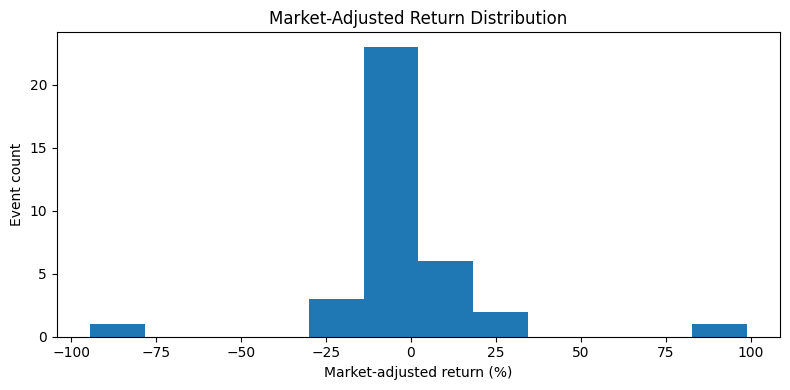

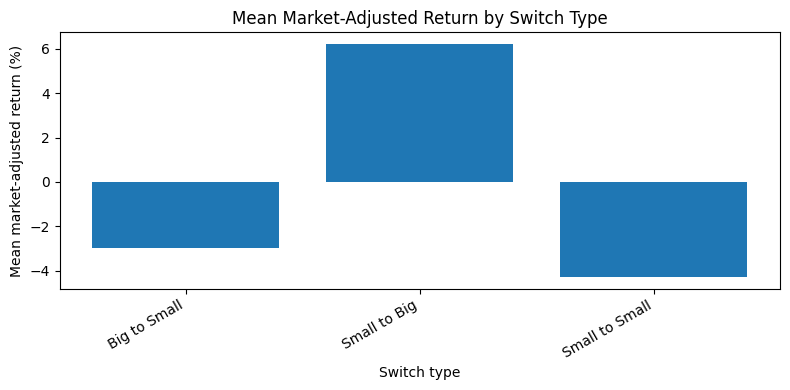

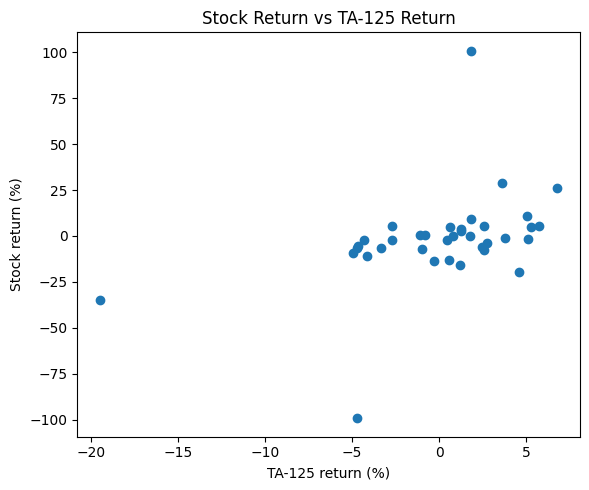

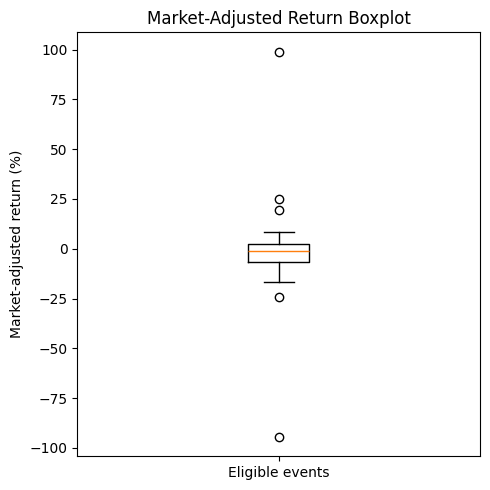

In [29]:
histogram_path = FIGURES_DIR / "market_adjusted_return_histogram_v01.png"
bar_path = FIGURES_DIR / "market_adjusted_return_by_switch_type_v01.png"
scatter_path = FIGURES_DIR / "stock_vs_market_return_scatter_v01.png"
boxplot_path = FIGURES_DIR / "market_adjusted_return_boxplot_v01.png"

if not eligible_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(eligible_df["market_adjusted_return_pct"].dropna(), bins=12)
    ax.set_title("Market-Adjusted Return Distribution")
    ax.set_xlabel("Market-adjusted return (%)")
    ax.set_ylabel("Event count")
    plt.tight_layout()
    plt.savefig(histogram_path, dpi=150)
    plt.show()

    switch_plot_df = dashboard_switch_type_summary_df.dropna(subset=["mean_market_adjusted_return_pct"])
    if not switch_plot_df.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(switch_plot_df["switch_type"].astype(str), switch_plot_df["mean_market_adjusted_return_pct"])
        ax.set_title("Mean Market-Adjusted Return by Switch Type")
        ax.set_xlabel("Switch type")
        ax.set_ylabel("Mean market-adjusted return (%)")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(bar_path, dpi=150)
        plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(eligible_df["ta125_return_pct"], eligible_df["stock_return_pct"])
    ax.set_title("Stock Return vs TA-125 Return")
    ax.set_xlabel("TA-125 return (%)")
    ax.set_ylabel("Stock return (%)")
    plt.tight_layout()
    plt.savefig(scatter_path, dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.boxplot(eligible_df["market_adjusted_return_pct"].dropna(), vert=True)
    ax.set_title("Market-Adjusted Return Boxplot")
    ax.set_ylabel("Market-adjusted return (%)")
    ax.set_xticklabels(["Eligible events"])
    plt.tight_layout()
    plt.savefig(boxplot_path, dpi=150)
    plt.show()
else:
    warnings.warn("No eligible rows are available; QA figures were not created.")

## 13. Figures for QA and Dashboard Reference

The figures are simple quality-assurance and dashboard-reference visuals. They should be interpreted descriptively.

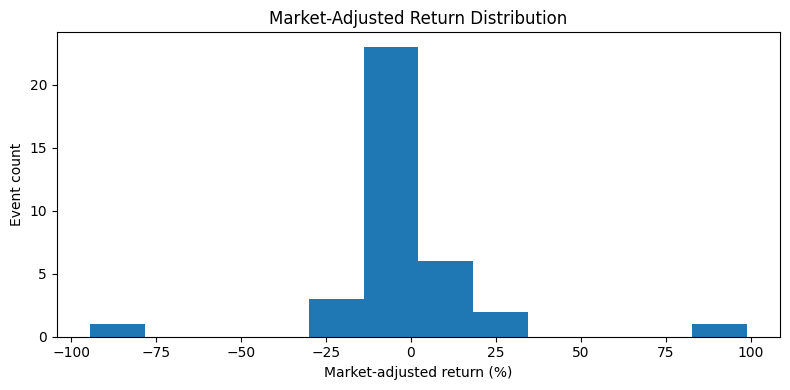

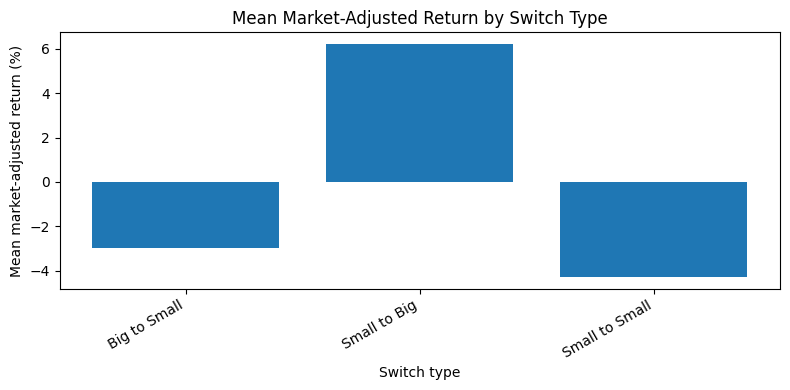

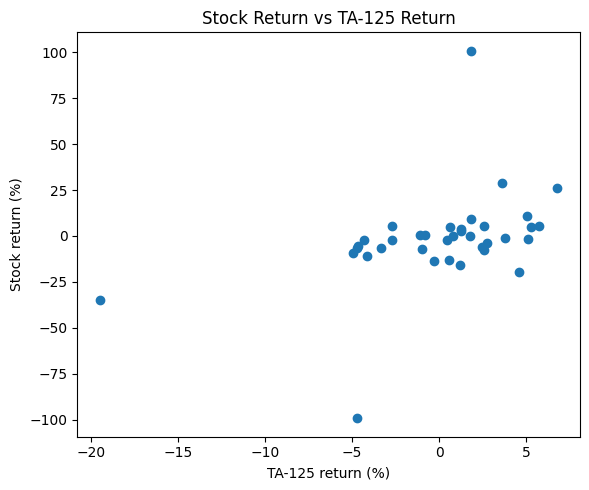

In [30]:
histogram_path = FIGURES_DIR / "market_adjusted_return_histogram_v01.png"
bar_path = FIGURES_DIR / "market_adjusted_return_by_switch_type_v01.png"
scatter_path = FIGURES_DIR / "stock_vs_market_return_scatter_v01.png"

if not eligible_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(eligible_df["market_adjusted_return_pct"].dropna(), bins=12)
    ax.set_title("Market-Adjusted Return Distribution")
    ax.set_xlabel("Market-adjusted return (%)")
    ax.set_ylabel("Event count")
    plt.tight_layout()
    plt.savefig(histogram_path, dpi=150)
    plt.show()

    switch_plot_df = dashboard_switch_type_summary_df.dropna(subset=["mean_market_adjusted_return_pct"])
    if not switch_plot_df.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(switch_plot_df["switch_type"].astype(str), switch_plot_df["mean_market_adjusted_return_pct"])
        ax.set_title("Mean Market-Adjusted Return by Switch Type")
        ax.set_xlabel("Switch type")
        ax.set_ylabel("Mean market-adjusted return (%)")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(bar_path, dpi=150)
        plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(eligible_df["ta125_return_pct"], eligible_df["stock_return_pct"])
    ax.set_title("Stock Return vs TA-125 Return")
    ax.set_xlabel("TA-125 return (%)")
    ax.set_ylabel("Stock return (%)")
    plt.tight_layout()
    plt.savefig(scatter_path, dpi=150)
    plt.show()
else:
    warnings.warn("No eligible rows are available; QA figures were not created.")

## 14. Methodology Notes File

The methodology note is saved as Markdown for direct use by the final dashboard or accompanying academic documentation.

In [31]:
methodology_notes_path = DATA_OUTPUT_DIR / "dashboard_methodology_notes_v01.md"

methodology_notes = f"""# Auditor Switch Event Study — Methodology Notes

## Research Objective

The project examines preliminary market reaction around auditor-switch events among Israeli public companies, with particular attention to transitions involving Big-4 and non-Big-4 auditors.

## Event Definition

The baseline event date is the auditor-switch date preserved in the event dataset. The project also preserves publication-date fields where available for later robustness checks.

## Event Window Definition

The event window is `{EVENT_WINDOW_LABEL}` using trading days. If the event calendar date is not a trading day, the event trading date is the nearest available trading day on or after the event date.

## Benchmark Definition

TA-125 is used as the broad market benchmark for market-adjusted return calculations.

## Return Formulas

stock_return = stock_price_t_plus_5 / stock_price_t_minus_5 - 1

ta125_return = ta125_price_t_plus_5 / ta125_price_t_minus_5 - 1

## Market-Adjusted Return Formula

market_adjusted_return = stock_return - ta125_return

## Inclusion Criteria

Rows are included in return calculations only when stock and TA-125 event-window prices are available, positive, and associated with OK price-status flags.

## Exclusion Reasons

Rows may be excluded due to missing tickers, ticker validation failures, future event dates, missing stock prices, missing market prices, non-positive prices, or insufficient trading days before or after the event.

## Outlier and Robustness Treatment

Extreme returns are retained in the main results. The dashboard also reports sensitivity metrics excluding events with absolute market-adjusted return above 20%.

These robustness metrics are descriptive and do not replace formal econometric testing. Extreme observations may reflect genuine market reactions, ticker issues, corporate actions, low liquidity, or event-date problems.

## Limitations

The dashboard provides preliminary descriptive evidence. The results should not be interpreted as causal evidence. Additional controls and robustness checks are required for formal inference.

Important limitations include possible mapping uncertainty, missing or unavailable market data, firm-specific confounders, sector effects, liquidity differences, concurrent corporate news, earnings announcements, and market microstructure effects.

## Interpretation Guidance for the Dashboard

Market-adjusted returns should be read as descriptive event-window reactions relative to TA-125. They do not prove that the auditor switch caused the observed price movement. Dashboard users should review exclusion counts, ticker validation status, event eligibility, and outlier flags before interpreting the results.
"""

methodology_notes_path.write_text(methodology_notes, encoding="utf-8")
print(methodology_notes_path.relative_to(PROJECT_ROOT))

data\output\dashboard_methodology_notes_v01.md


## 15. Validation Checks

Structural validation failures should stop the notebook. Ordinary data limitations remain documented in output tables and should not crash the workflow.

In [32]:
required_output_files = [
    event_study_results_csv_path,
    event_study_results_xlsx_path,
    kpi_csv_path,
    kpi_json_path,
    switch_summary_csv_path,
    switch_summary_xlsx_path,
    top_positive_csv_path,
    top_negative_csv_path,
    exclusion_report_csv_path,
    data_quality_summary_csv_path,
    methodology_notes_path,
]

if len(event_study_results_df) != len(event_window_df):
    raise ValueError(
        f"event_study_results_v01 row count differs from event_window_prices_v01: {len(event_study_results_df)} vs {len(event_window_df)}"
    )

missing_files = [str(path.relative_to(PROJECT_ROOT)) for path in required_output_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Required output files were not created: {missing_files}")

eligible_missing_returns = event_study_results_df.loc[
    event_study_results_df["analysis_eligible"]
    & event_study_results_df[["stock_return", "ta125_return", "market_adjusted_return"]].isna().any(axis=1)
]
if not eligible_missing_returns.empty:
    raise ValueError("Some analysis-eligible rows have missing return calculations.")

noneligible_included = event_study_results_df.loc[
    ~event_study_results_df["analysis_eligible"]
    & event_study_results_df["analysis_exclusion_reason"].eq("INCLUDED")
]
if not noneligible_included.empty:
    raise ValueError("Some non-eligible rows have analysis_exclusion_reason == INCLUDED.")

eligible_not_included = event_study_results_df.loc[
    event_study_results_df["analysis_eligible"]
    & ~event_study_results_df["analysis_exclusion_reason"].eq("INCLUDED")
]
if not eligible_not_included.empty:
    raise ValueError("Some eligible rows do not have analysis_exclusion_reason == INCLUDED.")

if len(dashboard_summary_kpis_df) != 1:
    raise ValueError("Dashboard KPI table must contain exactly one row.")

input_switch_types = set(event_window_df["switch_type"].dropna().astype(str))
summary_switch_types = set(dashboard_switch_type_summary_df["switch_type"].dropna().astype(str))
missing_switch_types = sorted(input_switch_types - summary_switch_types)
if missing_switch_types:
    raise ValueError(f"Switch-type summary is missing switch types from input: {missing_switch_types}")

if event_study_results_df["event_id"].nunique() != event_window_df["event_id"].nunique():
    raise ValueError("One or more event rows may have been silently dropped.")

validation_summary = {
    "event_window_rows": int(len(event_window_df)),
    "event_study_rows": int(len(event_study_results_df)),
    "required_files_created": len(missing_files) == 0,
    "eligible_rows": int(event_study_results_df["analysis_eligible"].sum()),
    "excluded_rows": int((~event_study_results_df["analysis_eligible"]).sum()),
}
validation_summary

{'event_window_rows': 50,
 'event_study_rows': 50,
 'required_files_created': True,
 'eligible_rows': 36,
 'excluded_rows': 14}

## Notebook 04 Conclusions

The conclusion below is generated from the current run. These results are descriptive and are prepared for the final Streamlit dashboard.

In [33]:
from IPython.display import Markdown, display

total_events_processed = len(event_study_results_df)
eligible_events = int(event_study_results_df["analysis_eligible"].sum())
excluded_events = int((~event_study_results_df["analysis_eligible"]).sum())
average_stock_return = kpis["mean_stock_return"]
average_ta125_return = kpis["mean_ta125_return"]
average_market_adjusted_return = kpis["mean_market_adjusted_return"]
outlier_20_count = kpis["number_of_20pct_outliers"]
outlier_50_count = kpis["number_of_50pct_outliers"]

eligible_switch_summary = dashboard_switch_type_summary_df.dropna(subset=["mean_market_adjusted_return"])
if not eligible_switch_summary.empty:
    highest_switch_type = eligible_switch_summary.sort_values("mean_market_adjusted_return", ascending=False).iloc[0]["switch_type"]
    lowest_switch_type = eligible_switch_summary.sort_values("mean_market_adjusted_return", ascending=True).iloc[0]["switch_type"]
else:
    highest_switch_type = "Not available"
    lowest_switch_type = "Not available"

optional_dashboard_files = [
    globals().get("stat_summary_csv_path"),
    globals().get("histogram_path"),
    globals().get("bar_path"),
    globals().get("scatter_path"),
    globals().get("boxplot_path"),
]
dashboard_files = required_output_files + [path for path in optional_dashboard_files if path is not None]
dashboard_files_text = "\n".join(
    f"- `{path.relative_to(PROJECT_ROOT)}`"
    for path in dashboard_files
    if path.exists()
)

conclusion = f"""
### Notebook 04 Conclusions

- Total events processed: **{total_events_processed}**.
- Events eligible for return calculation: **{eligible_events}**.
- Events excluded from return calculation: **{excluded_events}**.
- Average stock return: **{average_stock_return:.4f}**.
- Average TA-125 return: **{average_ta125_return:.4f}**.
- Average market-adjusted return: **{average_market_adjusted_return:.4f}**.
- 20% outlier count: **{outlier_20_count}**.
- 50% outlier count: **{outlier_50_count}**.
- Switch type with highest mean market-adjusted return: **{highest_switch_type}**.
- Switch type with lowest mean market-adjusted return: **{lowest_switch_type}**.

Files saved for the dashboard:
{dashboard_files_text}

The results are descriptive and should not be interpreted as causal evidence. The next step is to build the Streamlit dashboard using the dashboard-ready analytical tables produced here.
"""

display(Markdown(conclusion))


### Notebook 04 Conclusions

- Total events processed: **50**.
- Events eligible for return calculation: **36**.
- Events excluded from return calculation: **14**.
- Average stock return: **-0.0162**.
- Average TA-125 return: **0.0008**.
- Average market-adjusted return: **-0.0169**.
- 20% outlier count: **4**.
- 50% outlier count: **2**.
- Switch type with highest mean market-adjusted return: **Small to Big**.
- Switch type with lowest mean market-adjusted return: **Small to Small**.

Files saved for the dashboard:
- `data\output\event_study_results_v01.csv`
- `data\output\event_study_results_v01.xlsx`
- `data\output\dashboard_summary_kpis_v01.csv`
- `data\output\dashboard_summary_kpis_v01.json`
- `data\output\dashboard_switch_type_summary_v01.csv`
- `data\output\dashboard_switch_type_summary_v01.xlsx`
- `data\output\dashboard_top_positive_reactions_v01.csv`
- `data\output\dashboard_top_negative_reactions_v01.csv`
- `data\output\dashboard_exclusion_report_v01.csv`
- `data\output\dashboard_data_quality_summary_v01.csv`
- `data\output\dashboard_methodology_notes_v01.md`
- `data\output\exploratory_statistical_summary_v01.csv`
- `reports\figures\market_adjusted_return_histogram_v01.png`
- `reports\figures\market_adjusted_return_by_switch_type_v01.png`
- `reports\figures\stock_vs_market_return_scatter_v01.png`
- `reports\figures\market_adjusted_return_boxplot_v01.png`

The results are descriptive and should not be interpreted as causal evidence. The next step is to build the Streamlit dashboard using the dashboard-ready analytical tables produced here.
